# 02 -- Descriptive Funding Analytics

This notebook characterizes the empirical properties of perpetual-swap funding rates across four venues (BitMEX, Deribit, Bybit, Binance). Bybit is used as the primary analysis series because it has 7.3 years of clean native 8-hour data, covers all major stress events including Black Thursday, and shares structural features (base rate, hard cap) with the majority of exchanges.

All rates are displayed in annualized (APR) terms unless noted otherwise.

In [ ]:
import os, sys
from pathlib import Path as _Path

import ddx as _ddx
REPO_ROOT = _Path(_ddx.__file__).resolve().parent.parent.parent
os.chdir(REPO_ROOT)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats as sp_stats
from pathlib import Path
from IPython.display import display, Markdown

from ddx.data.io import load_processed
from ddx.risk.metrics import negative_episode_stats, extract_episodes, total_loss
from ddx.backtest.rolling import rolling_windows_regular, rolling_windows

INTERVALS_PER_YEAR = 365 * 24 / 8  # 1095

def to_apr(x):
    return x * INTERVALS_PER_YEAR

def to_apr_pct(x):
    return x * INTERVALS_PER_YEAR * 100

venues = {
    "Bybit": load_processed(REPO_ROOT / "data/processed/bybit_btcusd.parquet"),
    "BitMEX": load_processed(REPO_ROOT / "data/processed/bitmex_xbtusd.parquet"),
    "Deribit": load_processed(REPO_ROOT / "data/processed/deribit_btcperp.parquet"),
    "Binance": load_processed(REPO_ROOT / "data/processed/binance_btcusd.parquet"),
}
primary_name = "Bybit"
df = venues[primary_name]
cf = df["funding_cf"].values
ts = df["timestamp"]

for name, d in venues.items():
    n_irreg = int((~d["is_regular"]).sum()) if "is_regular" in d.columns else 0
    tag = " << PRIMARY" if name == primary_name else ""
    print(f"  {name}: {len(d):,} rows, {str(d['timestamp'].iloc[0])[:10]} to {str(d['timestamp'].iloc[-1])[:10]}, {n_irreg} irregular{tag}")

  Bybit: 7,971 rows, 2018-11-15 to 2026-02-23, 3 irregular << PRIMARY
  BitMEX: 10,675 rows, 2016-05-14 to 2026-02-23, 21 irregular
  Deribit: 7,474 rows, 2019-04-30 to 2026-02-23, 0 irregular
  Binance: 6,070 rows, 2020-08-10 to 2026-02-23, 0 irregular


## Section 1: Data Overview

In [ ]:
rows = []
for name, d in venues.items():
    c = d["funding_cf"].values
    n_irreg = int((~d["is_regular"]).sum()) if "is_regular" in d.columns else 0
    if "is_regular" in d.columns:
        w, _ = rolling_windows_regular(c, d["is_regular"].values, 90)
    else:
        w = rolling_windows(c, 90)
    rows.append({
        "Venue": name,
        "Start": str(d["timestamp"].iloc[0])[:10],
        "End": str(d["timestamp"].iloc[-1])[:10],
        "Rows": f"{len(d):,}",
        "Irregular": n_irreg,
        "Usable 30d Windows": f"{len(w):,}",
    })
display(pd.DataFrame(rows).set_index("Venue"))

,Start,End,Rows,Irregular,Usable 30d Windows
Venue,,,,,
Bybit,2018-11-15,2026-02-23,"7,971",3,"7,634"
BitMEX,2016-05-14,2026-02-23,"10,675",21,"10,564"
Deribit,2019-04-30,2026-02-23,"7,474",0,"7,385"
Binance,2020-08-10,2026-02-23,"6,070",0,"5,981"


## Section 2: Funding Rate Time Series

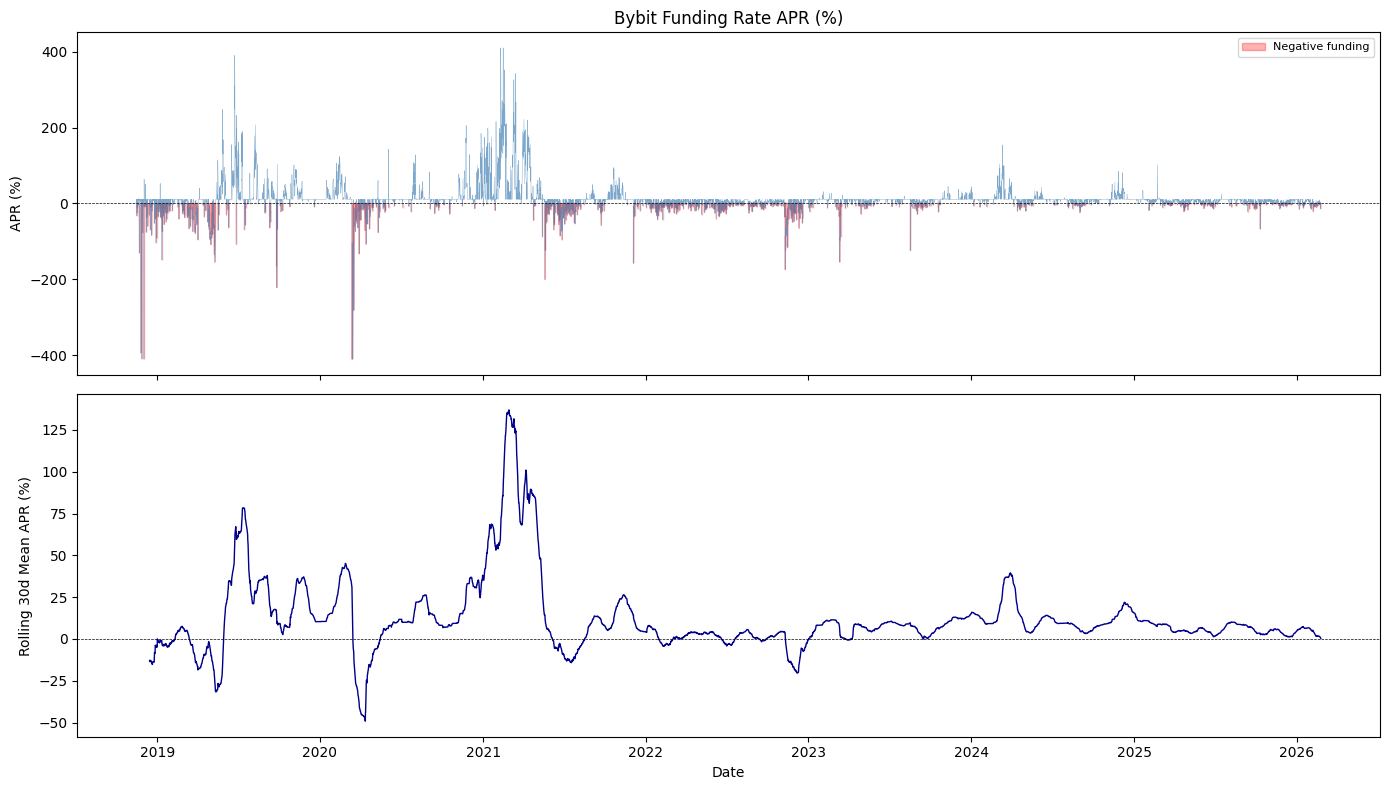

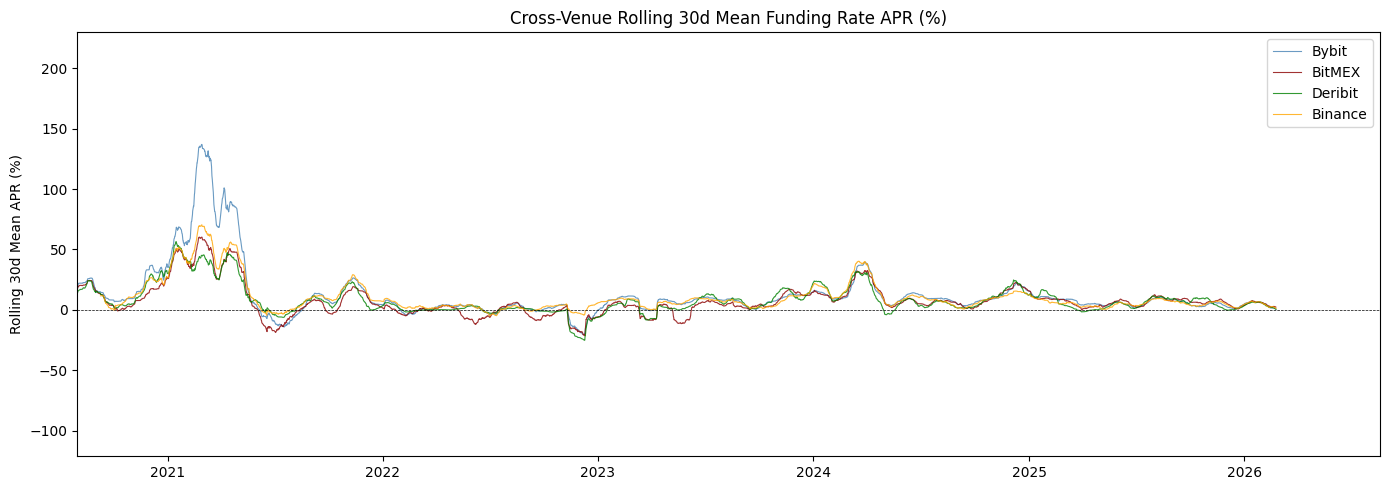

In [ ]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)
y = to_apr_pct(cf)
axes[0].plot(ts, y, linewidth=0.3, alpha=0.7, color="steelblue")
axes[0].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[0].fill_between(ts, y, 0, where=y < 0, alpha=0.3, color="red", label="Negative funding")
axes[0].set_ylabel("APR (%)")
axes[0].set_title(f"{primary_name} Funding Rate APR (%)")
axes[0].legend(fontsize=8)

roll = pd.Series(cf).rolling(90, min_periods=90).mean()
axes[1].plot(ts, to_apr_pct(roll), linewidth=1.0, color="darkblue")
axes[1].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[1].set_ylabel("Rolling 30d Mean APR (%)")
axes[1].set_xlabel("Date")
plt.tight_layout()
plt.show()

# Cross-venue rolling 30d mean overlay (overlapping period)
fig, ax = plt.subplots(figsize=(14, 5))
colors = {"Bybit": "steelblue", "BitMEX": "darkred", "Deribit": "green", "Binance": "orange"}
for name, d in venues.items():
    c = d["funding_cf"]
    r = to_apr_pct(c.rolling(90, min_periods=90).mean())
    ax.plot(d["timestamp"], r, linewidth=0.8, color=colors.get(name, "gray"), label=name, alpha=0.8)
ax.axhline(0, color="black", linewidth=0.5, linestyle="--")
ax.set_ylabel("Rolling 30d Mean APR (%)")
ax.set_title("Cross-Venue Rolling 30d Mean Funding Rate APR (%)")
ax.set_xlim(pd.Timestamp("2020-08-01", tz="UTC"), None)
ax.legend()
plt.tight_layout()
plt.show()

## Section 3: Distribution Analysis

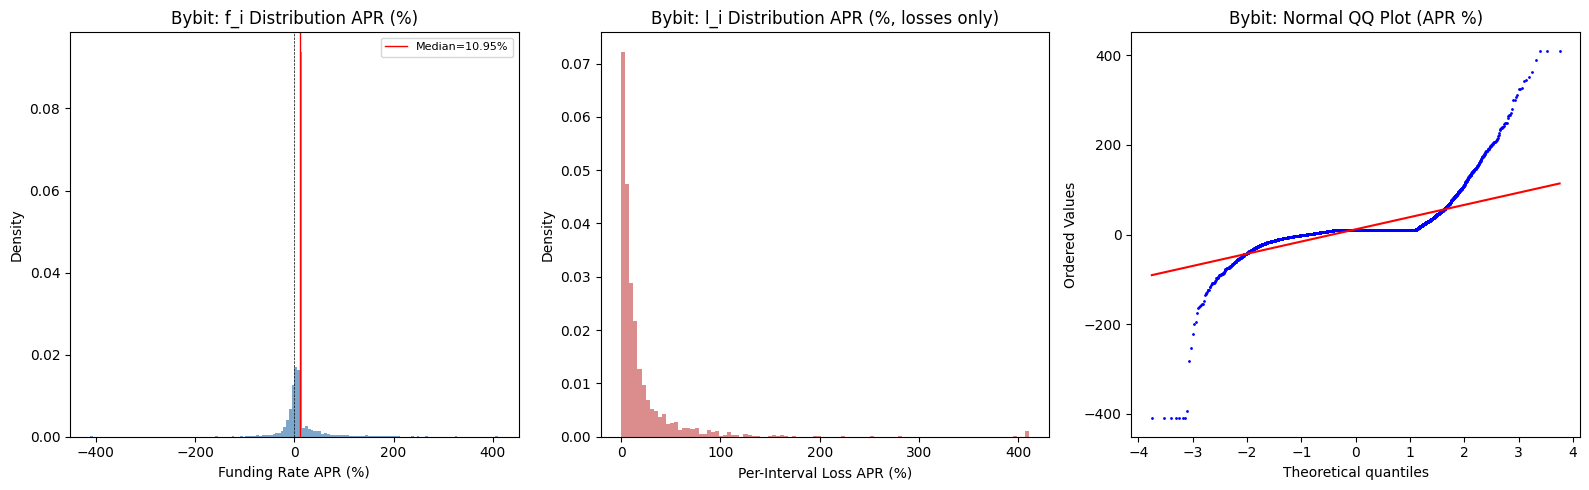

,Mean APR%,Median APR%,Std APR%,Skewness,Excess Kurtosis,% Negative
Venue,,,,,,
Bybit,11.68%,10.95%,37.61%,1.41,37.3,18.4%
BitMEX,10.35%,10.95%,86.50%,2.04,29.0,27.8%
Deribit,8.21%,1.52%,25.99%,-2.43,87.7,26.5%
Binance,10.07%,10.95%,20.57%,2.25,31.7,17.7%


In [ ]:
f_apr_pct = to_apr_pct(cf)
l_i_pct = np.maximum(0.0, -cf) * INTERVALS_PER_YEAR * 100

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
axes[0].hist(f_apr_pct, bins=150, density=True, alpha=0.7, color="steelblue", edgecolor="none")
axes[0].axvline(0, color="black", linewidth=0.5, linestyle="--")
med_val = float(np.median(f_apr_pct))
axes[0].annotate(f"Median = {med_val:.2f}%", xy=(0.97, 0.95), xycoords="axes fraction",
                 ha="right", va="top", fontsize=8,
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="gray", alpha=0.85))
axes[0].set_xlabel("Funding Rate APR (%)")
axes[0].set_ylabel("Density")
axes[0].set_title(f"{primary_name}: f_i Distribution APR (%)")

l_pos = l_i_pct[l_i_pct > 0]
if len(l_pos) > 0:
    axes[1].hist(l_pos, bins=100, density=True, alpha=0.7, color="indianred", edgecolor="none")
axes[1].set_xlabel("Per-Interval Loss APR (%)")
axes[1].set_ylabel("Density")
axes[1].set_title(f"{primary_name}: l_i Distribution APR (%, losses only)")

sp_stats.probplot(f_apr_pct, dist="norm", plot=axes[2])
axes[2].set_title(f"{primary_name}: Normal QQ Plot (APR %)")
axes[2].get_lines()[0].set_markersize(1)
plt.tight_layout()
plt.show()

# Cross-venue statistics table
rows = []
for name, d in venues.items():
    c = d["funding_cf"].values
    z = (c - np.mean(c)) / np.std(c, ddof=0)
    rows.append({
        "Venue": name,
        "Mean APR%": f"{to_apr_pct(np.mean(c)):.2f}%",
        "Median APR%": f"{to_apr_pct(np.median(c)):.2f}%",
        "Std APR%": f"{to_apr_pct(np.std(c)):.2f}%",
        "Skewness": f"{float(np.mean(z**3)):.2f}",
        "Excess Kurtosis": f"{float(np.mean(z**4) - 3):.1f}",
        "% Negative": f"{float(np.mean(c < 0) * 100):.1f}%",
    })
display(pd.DataFrame(rows).set_index("Venue"))

## Section 4: Negative Episode Analysis

,Episodes,Mean Duration (intervals),Max Duration,Mean Severity APR (%),Total Loss APR (%)
Venue,,,,,
Bybit,725,2.0,23,14.46%,29629.28%
BitMEX,1058,2.8,42,31.60%,148537.52%
Deribit,481,4.1,68,3.27%,14440.98%
Binance,560,1.9,23,7.77%,9653.37%


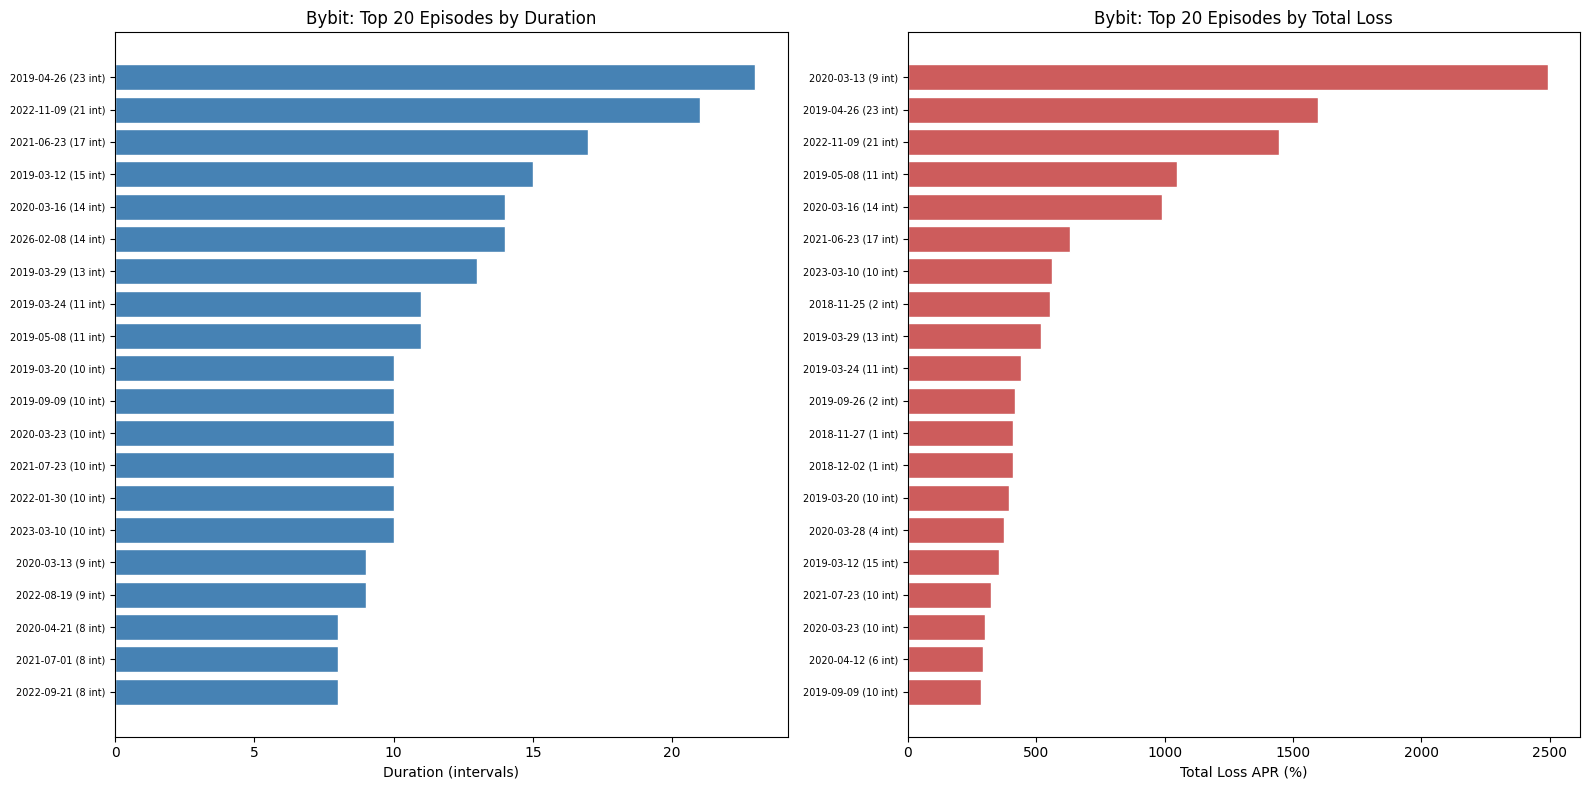

In [ ]:
# Cross-venue episode summary
rows = []
for name, d in venues.items():
    c = d["funding_cf"].values
    es = negative_episode_stats(c)
    rows.append({
        "Venue": name,
        "Episodes": es["count"],
        "Mean Duration (intervals)": f"{es['mean_duration']:.1f}",
        "Max Duration": es["max_duration"],
        "Mean Severity APR (%)": f"{to_apr_pct(es['mean_severity_per_interval']):.2f}%",
        "Total Loss APR (%)": f"{to_apr_pct(es['total_loss']):.2f}%",
    })
display(pd.DataFrame(rows).set_index("Venue"))

# Top 20 episodes by duration and severity for Bybit
episodes = extract_episodes(cf)
eps_sorted_dur = sorted(episodes, key=lambda e: e["duration"], reverse=True)[:20]
eps_sorted_sev = sorted(episodes, key=lambda e: e["total_loss"], reverse=True)[:20]

fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# By duration
eps = list(reversed(eps_sorted_dur))
labels = [f"{pd.Timestamp(ts.iloc[e['start_idx']]).strftime('%Y-%m-%d')} ({e['duration']} int)" for e in eps]
vals = [e["duration"] for e in eps]
axes[0].barh(range(len(vals)), vals, color="steelblue", edgecolor="white")
axes[0].set_yticks(range(len(labels)))
axes[0].set_yticklabels(labels, fontsize=7)
axes[0].set_xlabel("Duration (intervals)")
axes[0].set_title(f"{primary_name}: Top 20 Episodes by Duration")

# By severity (APR %)
eps2 = list(reversed(eps_sorted_sev))
labels2 = [f"{pd.Timestamp(ts.iloc[e['start_idx']]).strftime('%Y-%m-%d')} ({e['duration']} int)" for e in eps2]
vals2 = [to_apr_pct(e["total_loss"]) for e in eps2]
axes[1].barh(range(len(vals2)), vals2, color="indianred", edgecolor="white")
axes[1].set_yticks(range(len(labels2)))
axes[1].set_yticklabels(labels2, fontsize=7)
axes[1].set_xlabel("Total Loss APR (%)")
axes[1].set_title(f"{primary_name}: Top 20 Episodes by Total Loss")

plt.tight_layout()
plt.show()

## Section 5: Streak Length Distributions

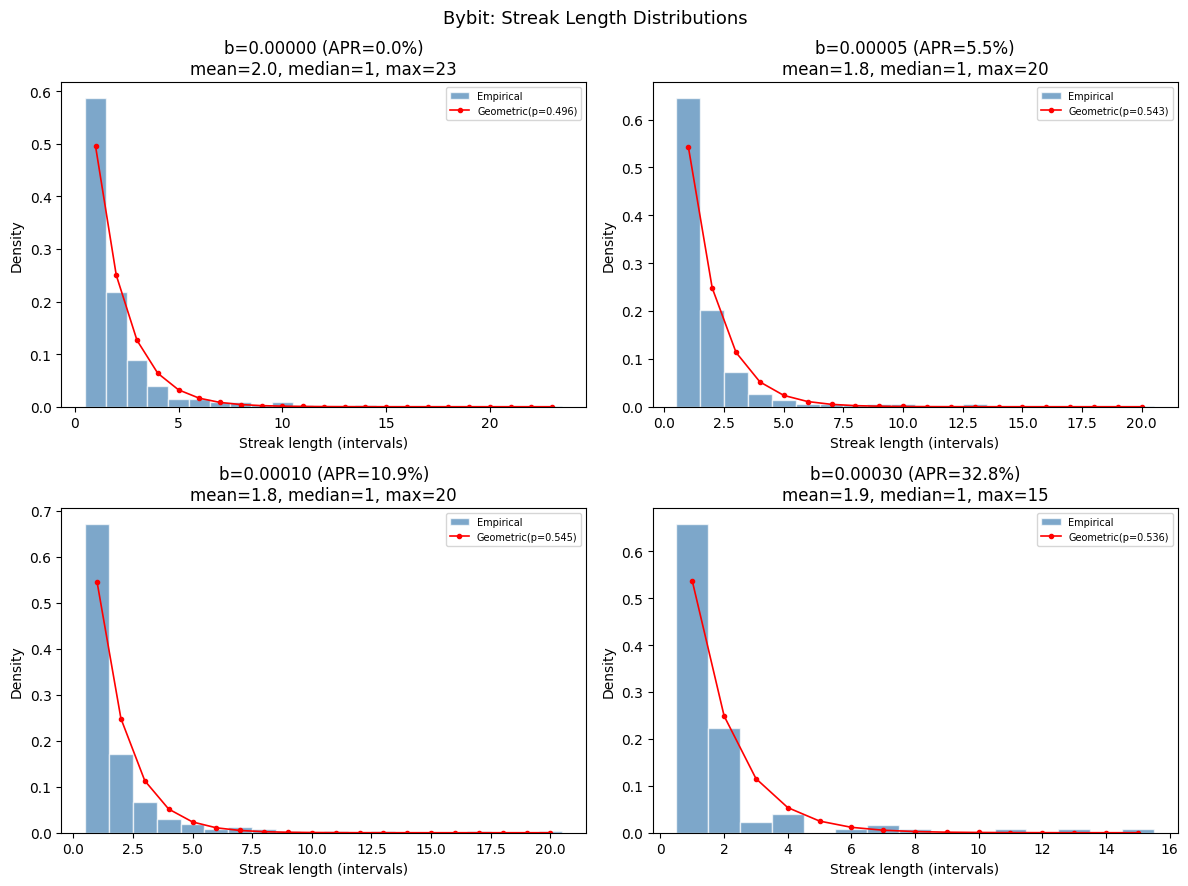

In [ ]:
def streak_lengths(funding_cf, threshold_b):
    bad = funding_cf < -threshold_b
    streaks = []
    current = 0
    for b in bad:
        if b:
            current += 1
        else:
            if current > 0:
                streaks.append(current)
            current = 0
    if current > 0:
        streaks.append(current)
    return np.array(streaks) if streaks else np.array([], dtype=int)

thresholds = [0.0, 0.00005, 0.0001, 0.0003]
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
axes = axes.flatten()

for idx, b in enumerate(thresholds):
    ax = axes[idx]
    sl = streak_lengths(cf, b)
    if len(sl) == 0:
        ax.set_title(f"b={b} (APR={to_apr_pct(b):.1f}%) -- no streaks")
        continue
    max_len = int(np.max(sl))
    bins = np.arange(0.5, min(max_len + 1.5, 40), 1)
    ax.hist(sl, bins=bins, density=True, alpha=0.7, color="steelblue", edgecolor="white", label="Empirical")
    
    mean_len = np.mean(sl)
    p_geom = 1.0 / mean_len if mean_len > 0 else 1.0
    k_range = np.arange(1, min(max_len + 1, 35))
    geom_pmf = (1 - p_geom) ** (k_range - 1) * p_geom
    ax.plot(k_range, geom_pmf, "r-o", markersize=3, linewidth=1.2, label=f"Geometric(p={p_geom:.3f})")
    
    ax.set_title(f"b={b:.5f} (APR={to_apr_pct(b):.1f}%)\nmean={mean_len:.1f}, median={np.median(sl):.0f}, max={max_len}")
    ax.set_xlabel("Streak length (intervals)")
    ax.set_ylabel("Density")
    ax.legend(fontsize=7)

fig.suptitle(f"{primary_name}: Streak Length Distributions", fontsize=13)
plt.tight_layout()
plt.show()

## Section 6: Empirical Markov Transition Tables

In [ ]:
def markov_transitions(funding_cf, threshold_b):
    bad = funding_cf < -threshold_b
    n = len(bad)
    bb = gg = bg = gb = 0
    for i in range(1, n):
        if bad[i-1] and bad[i]: bb += 1
        elif bad[i-1] and not bad[i]: bg += 1
        elif not bad[i-1] and bad[i]: gb += 1
        else: gg += 1
    t_bad = bb + bg
    t_good = gb + gg
    p_bb = bb / t_bad if t_bad > 0 else 0
    p_bg = bg / t_bad if t_bad > 0 else 0
    p_gb = gb / t_good if t_good > 0 else 0
    p_gg = gg / t_good if t_good > 0 else 0
    e_run = 1.0 / p_bg if p_bg > 0 else float("inf")
    return p_bb, p_bg, p_gb, p_gg, e_run, float(np.mean(bad)) * 100

markov_thresholds = [0.0, 0.0001, 0.0003]
rows = []
for name, d in venues.items():
    c = d["funding_cf"].values
    for b in markov_thresholds:
        p_bb, p_bg, p_gb, p_gg, e_run, pct_bad = markov_transitions(c, b)
        rows.append({
            "Venue": name,
            "Threshold (APR%)": f"{to_apr_pct(b):.1f}%",
            "P(bad->bad)": f"{p_bb:.4f}",
            "P(bad->good)": f"{p_bg:.4f}",
            "E[bad run] (intervals)": f"{e_run:.1f}",
            "E[bad run] (days)": f"{e_run * 8 / 24:.1f}",
            "% Time Bad": f"{pct_bad:.1f}%",
        })
display(pd.DataFrame(rows))

,Venue,Threshold (APR%),P(bad->bad),P(bad->good),E[bad run] (intervals),E[bad run] (days),% Time Bad
0,Bybit,0.0%,0.5048,0.4952,2.0,0.7,18.4%
1,Bybit,10.9%,0.4553,0.5447,1.8,0.6,7.7%
2,Bybit,32.8%,0.4638,0.5362,1.9,0.6,2.9%
3,BitMEX,0.0%,0.6439,0.3561,2.8,0.9,27.8%
4,BitMEX,10.9%,0.5997,0.4003,2.5,0.8,17.7%
5,BitMEX,32.8%,0.6018,0.3982,2.5,0.8,9.4%
6,Deribit,0.0%,0.7572,0.2428,4.1,1.4,26.5%
7,Deribit,10.9%,0.5686,0.4314,2.3,0.8,3.4%
8,Deribit,32.8%,0.5432,0.4568,2.2,0.7,1.1%
9,Binance,0.0%,0.4795,0.5205,1.9,0.6,17.7%


## Section 7: Rolling Regime Markers

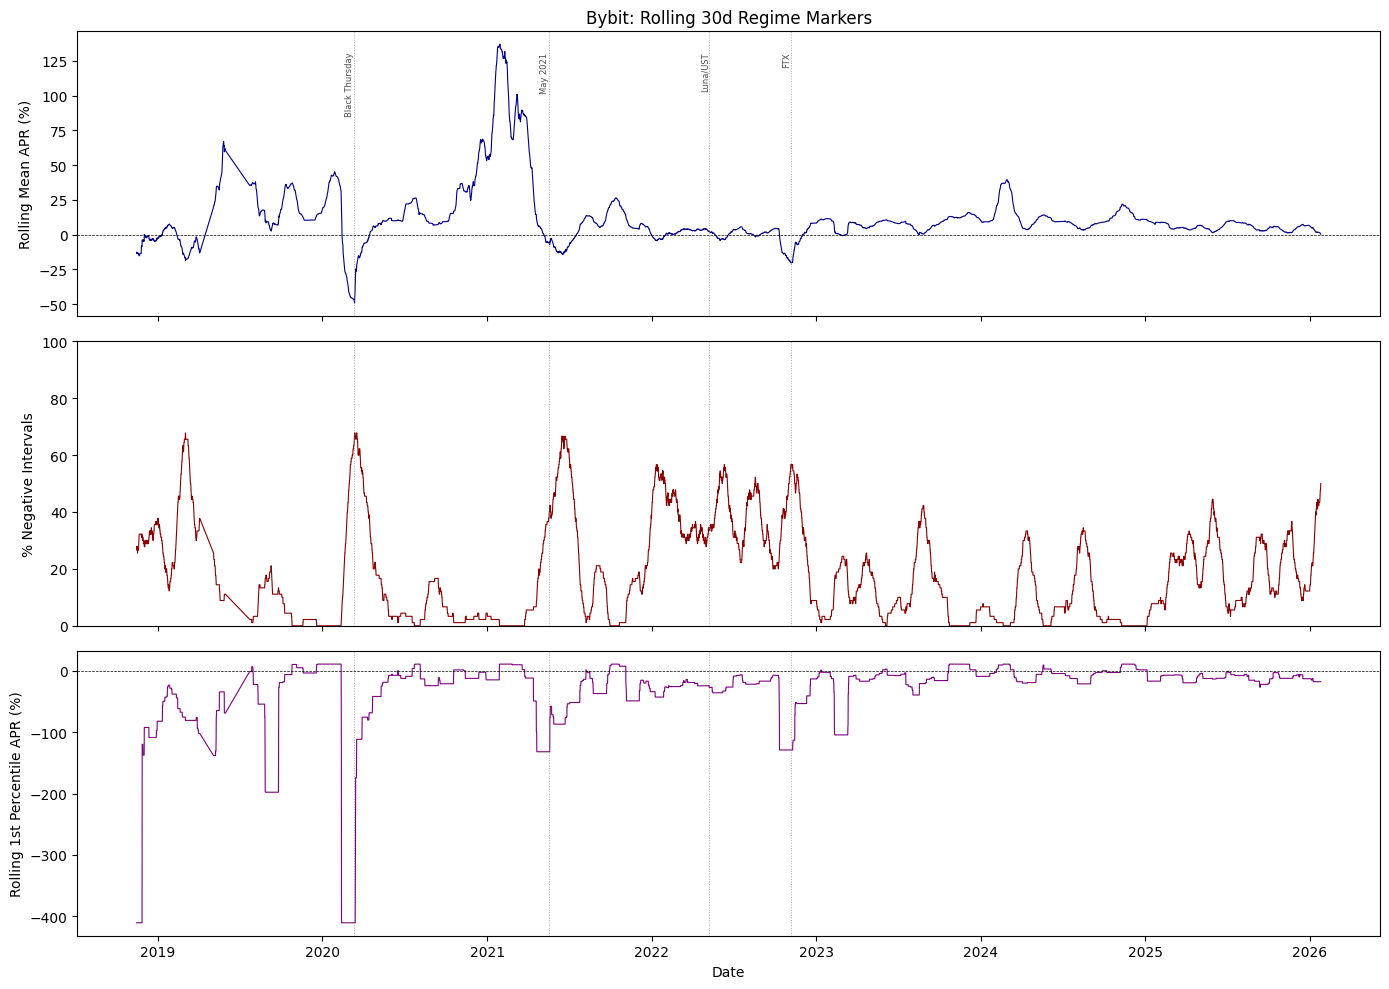

In [ ]:
window = 90
if "is_regular" in df.columns:
    wins, win_starts = rolling_windows_regular(cf, df["is_regular"].values, window)
else:
    wins = rolling_windows(cf, window)
    win_starts = np.arange(len(wins))

rolling_mean = np.mean(wins, axis=1)
rolling_pct_neg = np.mean(wins < 0, axis=1)
rolling_p01 = np.quantile(wins, 0.01, axis=1)
roll_ts = ts.iloc[win_starts].values

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)
axes[0].plot(roll_ts, to_apr_pct(rolling_mean), linewidth=0.8, color="darkblue")
axes[0].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[0].set_ylabel("Rolling Mean APR (%)")
axes[0].set_title(f"{primary_name}: Rolling 30d Regime Markers")

axes[1].plot(roll_ts, rolling_pct_neg * 100, linewidth=0.8, color="darkred")
axes[1].set_ylabel("% Negative Intervals")
axes[1].set_ylim(0, 100)

axes[2].plot(roll_ts, to_apr_pct(rolling_p01), linewidth=0.8, color="purple")
axes[2].axhline(0, color="black", linewidth=0.5, linestyle="--")
axes[2].set_ylabel("Rolling 1st Percentile APR (%)")
axes[2].set_xlabel("Date")

events = [
    (pd.Timestamp("2020-03-12", tz="UTC"), "Black Thursday"),
    (pd.Timestamp("2021-05-19", tz="UTC"), "May 2021"),
    (pd.Timestamp("2022-05-09", tz="UTC"), "Luna/UST"),
    (pd.Timestamp("2022-11-07", tz="UTC"), "FTX"),
]
for ax in axes:
    for dt, label in events:
        ax.axvline(dt, color="gray", linewidth=0.7, linestyle=":", alpha=0.7)
    for dt, label in events:
        if ax == axes[0]:
            ax.text(dt, ax.get_ylim()[1] * 0.9, label, fontsize=6, rotation=90, va="top", ha="right", alpha=0.7)

plt.tight_layout()
plt.show()

## Section 8: Tail Characterization

In [ ]:
# Per-interval loss quantiles (APR%)
q_levels = [0.50, 0.75, 0.90, 0.95, 0.99]
rows = []
for name, d in venues.items():
    c = d["funding_cf"].values
    losses = np.maximum(0.0, -c)
    row = {"Venue": name}
    for q in q_levels:
        row[f"l_i p{int(q*100)} (APR%)"] = f"{to_apr_pct(np.quantile(losses, q)):.2f}%"
    rows.append(row)
print("Per-Interval Loss Quantiles (APR%):")
display(pd.DataFrame(rows).set_index("Venue"))

# Rolling 30d aggregate loss Lambda quantiles (APR)
rows2 = []
for name, d in venues.items():
    c = d["funding_cf"].values
    if "is_regular" in d.columns:
        w, _ = rolling_windows_regular(c, d["is_regular"].values, 90)
    else:
        w = rolling_windows(c, 90)
    if len(w) == 0:
        continue
    lam = np.array([total_loss(win) for win in w])
    row = {"Venue": name}
    for q in q_levels:
        row[f"Lambda_30d p{int(q*100)} (% notional)"] = f"{np.quantile(lam, q) * 100:.4f}%"
    rows2.append(row)
print("\nRolling 30d Aggregate Loss (Lambda) Quantiles (% of notional per 30d window):")
display(pd.DataFrame(rows2).set_index("Venue"))

# Key finding
bybit_cf = venues["Bybit"]["funding_cf"].values
bybit_is_reg = venues["Bybit"]["is_regular"].values
w_by, _ = rolling_windows_regular(bybit_cf, bybit_is_reg, 90)
lam_by = np.array([total_loss(win) for win in w_by])
p99_notional = np.quantile(lam_by, 0.99) * 100
p75_notional = np.quantile(lam_by, 0.75) * 100
print(f"\nKey finding: To cover 99% of 30d windows on Bybit, reserve >= {p99_notional:.2f}% of notional")
print(f"75th percentile Lambda (for ASL deductible D): {p75_notional:.4f}% of notional")

Per-Interval Loss Quantiles (APR%):


,l_i p50 (APR%),l_i p75 (APR%),l_i p90 (APR%),l_i p95 (APR%),l_i p99 (APR%)
Venue,,,,,
Bybit,0.00%,0.00%,7.09%,18.59%,72.06%
BitMEX,0.00%,2.52%,29.89%,78.47%,265.29%
Deribit,0.00%,0.01%,2.07%,6.94%,36.65%
Binance,0.00%,0.00%,4.48%,10.26%,24.31%



Rolling 30d Aggregate Loss (Lambda) Quantiles APR (%):


,Lambda_30d p50 APR (%),Lambda_30d p75 APR (%),Lambda_30d p90 APR (%),Lambda_30d p95 APR (%),Lambda_30d p99 APR (%)
Venue,,,,,
Bybit,84.62%,282.87%,888.52%,1419.84%,3148.05%
BitMEX,317.39%,1472.97%,4578.25%,6069.91%,8242.94%
Deribit,26.03%,102.45%,425.26%,649.73%,2987.12%
Binance,86.16%,195.56%,362.59%,582.46%,694.83%



Key finding: To cover 99% of 30d windows on Bybit, reserve >= 3148.05% APR of notional
75th percentile Lambda (for ASL deductible D): 282.87% APR


## Section 9: Implications for Product Design

In [ ]:
losses_bybit = np.maximum(0.0, -bybit_cf)
l_i_p50 = float(np.quantile(losses_bybit, 0.50))
l_i_p50_apr_pct = to_apr_pct(l_i_p50)
lam_p75 = float(np.quantile(lam_by, 0.75))
lam_p75_pct = lam_p75 * 100

_, p_bg_b0, _, _, e_run_b0, _ = markov_transitions(bybit_cf, 0.0)
_, p_bg_b1, _, _, e_run_b1, _ = markov_transitions(bybit_cf, 0.0001)

print("=" * 60)
print("PARAMETER RECOMMENDATIONS (based on Bybit primary series)")
print("=" * 60)
print()
print("1. Vanilla Floor deductible d:")
print(f"   d = p50 of l_i = {l_i_p50:.6f} per-interval ({l_i_p50_apr_pct:.2f}% APR)")
print(f"   This filters out the smaller half of per-interval losses.")
print()
print("2. Aggregate Stop-Loss deductible D:")
print(f"   D = p75 of rolling 30d Lambda = {lam_p75:.6f} ({lam_p75_pct:.4f}% of notional per 30d)")
print(f"   The product activates in ~25% of 30d windows.")
print()
print("3. DAF/SDC streak threshold m:")
print(f"   At b=0: E[bad run] = {e_run_b0:.1f} intervals ({e_run_b0 * 8 / 24:.1f} days)")
print(f"   At b=0.0001 ({to_apr_pct(0.0001):.1f}% APR): E[bad run] = {e_run_b1:.1f} intervals ({e_run_b1 * 8 / 24:.1f} days)")
print(f"   Recommended m=2 (captures ~50% of streaks) or m=3 (captures ~33%)")
print()
print("4. Meaningful b thresholds:")
print(f"   b=0 (any negative): captures all {float(np.mean(bybit_cf < 0))*100:.1f}% of negative intervals")
print(f"   b=0.0001 ({to_apr_pct(0.0001):.1f}% APR): filters base-rate noise, captures severe negative")
print(f"   b=0.0003 ({to_apr_pct(0.0003):.1f}% APR): deep distress only")
print()
print("5. Cross-venue consistency:")
print(f"   Bybit, BitMEX, Binance share the 0.0001 base rate and similar cap structures.")
print(f"   Deribit is structurally different (no base rate, no cap, left-skewed).")
print(f"   Parameters calibrated on Bybit should transfer well to BitMEX/Binance")
print(f"   but may need adjustment for Deribit.")

PARAMETER RECOMMENDATIONS (based on Bybit primary series)

1. Vanilla Floor deductible d:
   d = p50 of l_i = 0.000000 per-interval = 0.0000 APR
   This filters out the smaller half of per-interval losses.

2. Aggregate Stop-Loss deductible D:
   D = p75 of rolling 30d Lambda = 0.002583 per-interval = 2.8287 APR
   The product activates in ~25% of 30d windows.

3. DAF/SDC streak threshold m:
   At b=0: E[bad run] = 2.0 intervals (0.7 days)
   At b=0.0001 (10.9% APR): E[bad run] = 1.8 intervals (0.6 days)
   Recommended m=2 (captures ~50% of streaks) or m=3 (captures ~33%)

4. Meaningful b thresholds:
   b=0 (any negative): captures all 18.4% of negative intervals
   b=0.0001 (10.9% APR): filters base-rate noise, captures severe negative
   b=0.0003 (32.8% APR): deep distress only

5. Cross-venue consistency:
   Bybit, BitMEX, Binance share the 0.0001 base rate and similar cap structures.
   Deribit is structurally different (no base rate, no cap, left-skewed).
   Parameters calibrated 